# About Dataset

link https://www.kaggle.com/datasets/ishans24/brain-tumor-dataset

This dataset is a unified collection of Brain MRI scans compiled from multiple publicly available datasets on Kaggle and Figshare. The goal is to provide a larger, more diverse dataset for training and evaluating deep learning models for brain tumor classification.

Context -


Brain tumors are among the most aggressive diseases, with MRI (Magnetic Resonance Imaging) being the standard imaging technique for diagnosis and treatment planning. Existing datasets are often limited in size or restricted to specific tumor classes, which can lead to models that fail to generalize well. By combining several well-known datasets, this collection provides broader coverage across tumor types, imaging conditions, and sources.

## Imports

In [19]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import kagglehub

## Load the data

In [2]:
# Download latest version
path = kagglehub.dataset_download("ishans24/brain-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 862M/862M [00:06<00:00, 147MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ishans24/brain-tumor-dataset/versions/1


In [3]:
print(os.listdir(path))

['pituitary', 'glioma', 'meningioma', 'no_tumor']


Load the images in below formate you can use below code in any data set which have multiple folders in it

In [6]:
image_paths = []
labels = []

for folder in os.listdir(path):
    folder_path = os.path.join(path, folder)
    if os.path.isdir(folder_path):
        for image_file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_file)
            image_paths.append(image_path)
            labels.append(folder)

# Create a pandas DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})

display(df.head())

,image_path,label
0,/root/.cache/kagglehub/datasets/ishans24/brain...,pituitary
1,/root/.cache/kagglehub/datasets/ishans24/brain...,pituitary
2,/root/.cache/kagglehub/datasets/ishans24/brain...,pituitary
3,/root/.cache/kagglehub/datasets/ishans24/brain...,pituitary
4,/root/.cache/kagglehub/datasets/ishans24/brain...,pituitary


## Explore the data

In [16]:
from tensorflow.keras.preprocessing.image import load_img

# Load the image first
img = load_img(df['image_path'][0])

# Now access the shape of the loaded image
print(np.shape(img))

(400, 350, 3)


In [10]:
df['label'].value_counts()

,count
label,
glioma,3754
pituitary,2706
meningioma,2343
no_tumor,1757


Rows: 10560
                                          image_path      label
0  /root/.cache/kagglehub/datasets/ishans24/brain...  pituitary
1  /root/.cache/kagglehub/datasets/ishans24/brain...  pituitary
2  /root/.cache/kagglehub/datasets/ishans24/brain...  pituitary

Label counts:
label
glioma        3754
pituitary     2706
meningioma    2343
no_tumor      1757
Name: count, dtype: int64

Missing files: 0


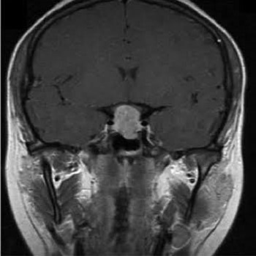

Label: pituitary


In [9]:
# If your dataframe is named something else, rename it to df first
# df.head() should show columns: image_path, label

import os, pandas as pd

print("Rows:", len(df))
print(df.head(3)[['image_path','label']])

# 1) Check unique labels & counts
print("\nLabel counts:")
print(df['label'].value_counts())

# 2) Verify files actually exist on disk
missing = df.loc[~df['image_path'].apply(os.path.exists)]
print(f"\nMissing files: {len(missing)}")
if len(missing) > 0:
    display(missing.head(5))

# 3) Quick visual peek (optional)
from PIL import Image
i = 0
try:
    img = Image.open(df.loc[i,'image_path']).convert('RGB')
    display(img.resize((256,256)))
    print("Label:", df.loc[i,'label'])
except Exception as e:
    print("Problem opening sample image:", e)


## Preprocessing

In [12]:
classes = sorted(df['label'].unique().tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
df['y'] = df['label'].map(class_to_idx)

print("Class order (keep this):", classes)

Class order (keep this): ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## Stratified Shuffle Split

In [29]:
y = df['y'].values
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(np.zeros_like(y), y))
y_tv = y[train_val_idx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)  # ~15% of total
train_idx_rel, val_idx_rel = next(sss2.split(np.zeros_like(y_tv), y_tv))
train_idx = train_val_idx[train_idx_rel]
val_idx   = train_val_idx[val_idx_rel]

train_ds = df.iloc[train_idx].reset_index(drop=True)
val_ds   = df.iloc[val_idx].reset_index(drop=True)
test_ds  = df.iloc[test_idx].reset_index(drop=True)

# 3) Quick check of class balance in each split
print("\nTrain counts:\n", df_train['label'].value_counts())
print("\nVal counts:\n",   df_val['label'].value_counts())
print("\nTest counts:\n",  df_test['label'].value_counts())


Train counts:
 label
glioma        2628
pituitary     1894
meningioma    1640
no_tumor      1229
Name: count, dtype: int64

Val counts:
 label
glioma        563
pituitary     406
meningioma    352
no_tumor      264
Name: count, dtype: int64

Test counts:
 label
glioma        563
pituitary     406
meningioma    351
no_tumor      264
Name: count, dtype: int64


### Compute class weights (to handle imbalance)

In [30]:
train_counts = train_ds['label'].value_counts().reindex(sorted(df['label'].unique()))
N = train_counts.sum()
C = len(train_counts)

# Compute weights: total / (num_classes * class_count)
cls_weights = N / (C * train_counts)
cls_weights = cls_weights.to_numpy(dtype=float)

print("Class order:", list(train_counts.index))
print("Weights:", cls_weights)

Class order: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Weights: [0.70310122 1.12667683 1.5034581  0.97558078]


In [ ]:
# Define the augmentation layer
random_rotation_layer = tf.keras.layers.RandomRotation(factor=0.05)

@tf.function
def _map(path, label, training, class_weight_tensor):
    img = decode_img(path)
    if training:
        img = tf.image.random_flip_left_right(img)
        # Use the RandomRotation layer
        img = random_rotation_layer(img)
    img = preprocess(img)
    # Get sample weight for the label
    sample_weight = tf.gather(class_weight_tensor, label)
    return img, label, sample_weight

def make_ds(frame, training=False, class_weight=None):
    x = frame['image_path'].values
    y = frame['y'].values
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    # Convert class_weight dictionary to a tensor
    class_weight_tensor = tf.constant([class_weight[i] for i in sorted(class_weight.keys())], dtype=tf.float32)

    ds = ds.map(lambda path, label: _map(path, label, training, class_weight_tensor), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(8192, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

# Class weights from TRAIN split (to handle imbalance)
counts = df_train['y'].value_counts().reindex(range(num_classes), fill_value=0).values.astype(float)
N = counts.sum()
class_weight = {i: float(N/(num_classes*counts[i])) for i in range(num_classes)}
print("Class order:", classes)
print("Class weights:", class_weight)


train_ds = make_ds(df_train, training=True, class_weight=class_weight)
val_ds   = make_ds(df_val,   training=False, class_weight=class_weight) # Also include class weights for validation
test_ds  = make_ds(df_test,  training=False, class_weight=class_weight) # And for testing

# Quick sanity checks
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:",   tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:",  tf.data.experimental.cardinality(test_ds).numpy())

Class order: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Class weights: {0: 0.7031012176560122, 1: 1.1266768292682927, 2: 1.5034580960130186, 3: 0.9755807814149947}
Train batches: 231
Val batches: 50
Test batches: 50


## Define model

In [31]:
from tensorflow import keras
import tensorflow as tf

num_classes = len(classes)
IMG_SIZE = (224, 224)

# 5.1 Base (frozen) + small head
base = keras.applications.EfficientNetB0(
    include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet"
)
base.trainable = False  # we'll fine-tune later

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# 5.2 Compile
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)




In [32]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [37]:
EPOCHS = 5

cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("efb0_stage1.keras", monitor="val_loss", save_best_only=True)
]

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs,
    verbose=1
)

print("Best val acc so far:", max(hist.history["val_accuracy"]))

Epoch 1/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 112s 183ms/step - accuracy: 0.6325 - loss: 0.8577 - val_accuracy: 0.8347 - val_loss: 0.4486
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 103s 62ms/step - accuracy: 0.8327 - loss: 0.4434 - val_accuracy: 0.8543 - val_loss: 0.3737
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.8520 - loss: 0.3956 - val_accuracy: 0.8625 - val_loss: 0.3488
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 63ms/step - accuracy: 0.8638 - loss: 0.3638 - val_accuracy: 0.8688 - val_loss: 0.3351
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 63ms/step - accuracy: 0.8685 - loss: 0.3407 - val_accuracy: 0.8688 - val_loss: 0.3311
Best val acc so far: 0.8687697052955627


## Evaluate on the test set (confusion matrix + report)

In [39]:
import numpy as np, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 1) Collect predictions
y_true, y_pred = [], []
for xb, yb, sample_weight_b in test_ds: # Unpack all three values
    probs = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(yb.numpy())

# 2) Metrics
print("Class order:", classes)
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print("\nMacro F1:", macro_f1)

Class order: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

Classification report:
              precision    recall  f1-score   support

      glioma     0.9257    0.8188    0.8690       563
  meningioma     0.7303    0.6866    0.7078       351
    no_tumor     0.8968    0.9545    0.9248       264
   pituitary     0.8463    0.9901    0.9126       406

    accuracy                         0.8561      1584
   macro avg     0.8498    0.8625    0.8535      1584
weighted avg     0.8572    0.8561    0.8537      1584


Confusion matrix (rows=true, cols=pred):
 [[461  84   4  14]
 [ 34 241  23  53]
 [  1   5 252   6]
 [  2   0   2 402]]

Macro F1: 0.8535360377835824


## Fine-tune the top of EfficientNetB0 (low LR)

In [41]:
from tensorflow import keras
import tensorflow as tf

# 8.1 Unfreeze only the top blocks (safer than unfreezing all)
unfreeze_from = None
for i, layer in enumerate(model.layers[1].layers):  # model.layers[1] is the EfficientNet base
    if "block6" in layer.name or "block7" in layer.name:  # top ~20–30%
        unfreeze_from = i
        break

if unfreeze_from is None:
    unfreeze_from = max(0, len(model.layers[1].layers) - 60)  # fallback: last ~60 layers

for layer in model.layers[1].layers[unfreeze_from:]:
    layer.trainable = True

print("Unfreezing from layer index:", unfreeze_from, "→", model.layers[1].layers[unfreeze_from].name)

# 8.2 Re-compile with a SMALL learning rate (+ weight decay)
opt = keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)

model.compile(
    optimizer=opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 8.3 Train briefly with early stopping
cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("efb0_ft.keras", monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6)
]

hist_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=cbs,
    verbose=1
)
print("Best fine-tune val acc:", max(hist_ft.history["val_accuracy"]))

Unfreezing from layer index: 163 → block6a_expand_conv
Epoch 1/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 136s 210ms/step - accuracy: 0.8248 - loss: 0.4422 - val_accuracy: 0.9350 - val_loss: 0.1824 - learning_rate: 1.0000e-04
Epoch 2/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 68s 86ms/step - accuracy: 0.9356 - loss: 0.1700 - val_accuracy: 0.9527 - val_loss: 0.1425 - learning_rate: 1.0000e-04
Epoch 3/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 70s 87ms/step - accuracy: 0.9607 - loss: 0.1036 - val_accuracy: 0.9691 - val_loss: 0.0994 - learning_rate: 1.0000e-04
Epoch 4/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 81ms/step - accuracy: 0.9757 - loss: 0.0728 - val_accuracy: 0.9741 - val_loss: 0.0821 - learning_rate: 1.0000e-04
Epoch 5/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - accuracy: 0.9813 - loss: 0.0533 - val_accuracy: 0.9792 - val_loss: 0.0750 - learning_rate: 1.0000e-04
Epoch 6/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.9863 - loss: 0.0398 - val_accuracy: 0.9785 - val_loss: 0.0752 - learning_rate: 1.0000e-04


## Test evaluation (after fine-tune)

In [43]:
y_true, y_pred = [], []
for xb, yb, sample_weight_b in test_ds:
    probs = model.predict(xb, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(yb.numpy())

print("Class order:", classes)
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print("\nMacro F1:", macro_f1)


Class order: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

Classification report:
              precision    recall  f1-score   support

      glioma     0.9719    0.9822    0.9770       563
  meningioma     0.9561    0.9316    0.9437       351
    no_tumor     0.9961    0.9773    0.9866       264
   pituitary     0.9734    0.9926    0.9829       406

    accuracy                         0.9729      1584
   macro avg     0.9744    0.9709    0.9726      1584
weighted avg     0.9728    0.9729    0.9728      1584


Confusion matrix (rows=true, cols=pred):
 [[553   9   1   0]
 [ 14 327   0  10]
 [  2   3 258   1]
 [  0   3   0 403]]

Macro F1: 0.9725743134719171


## Overfitting check

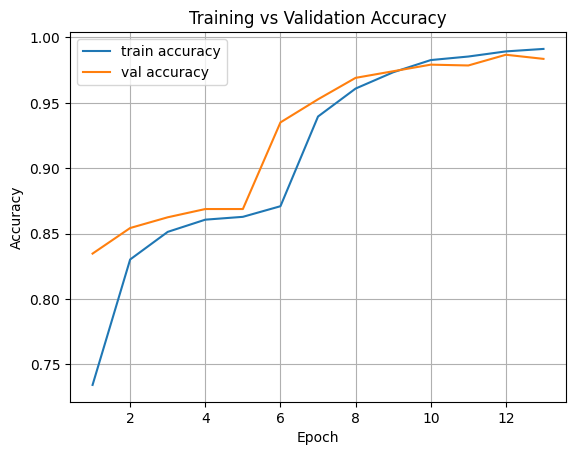

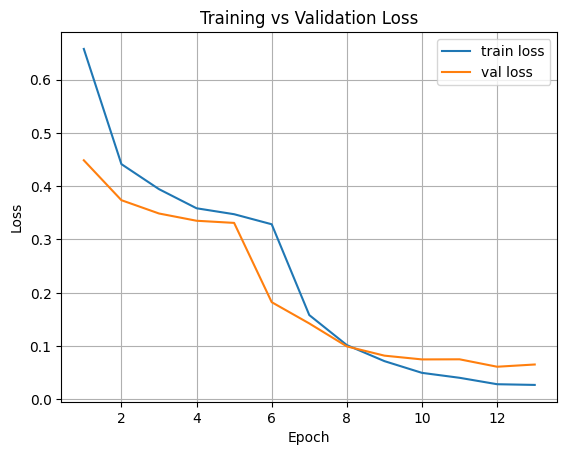

Total epochs plotted: 13 (stage1=5, finetune=8)


In [44]:
import matplotlib.pyplot as plt

# Collect histories safely (stage-1: hist, fine-tune: hist_ft)
def get_series(h, key):
    return h.history.get(key, []) if h is not None else []

h1_acc  = get_series(globals().get("hist"),   "accuracy")
h1_vacc = get_series(globals().get("hist"),   "val_accuracy")
h1_loss = get_series(globals().get("hist"),   "loss")
h1_vloss= get_series(globals().get("hist"),   "val_loss")

h2_acc  = get_series(globals().get("hist_ft"),"accuracy")
h2_vacc = get_series(globals().get("hist_ft"),"val_accuracy")
h2_loss = get_series(globals().get("hist_ft"),"loss")
h2_vloss= get_series(globals().get("hist_ft"),"val_loss")

acc   = h1_acc  + h2_acc
val_acc = h1_vacc + h2_vacc
loss  = h1_loss + h2_loss
val_loss = h1_vloss + h2_vloss

# — Accuracy —
plt.figure()
plt.plot(range(1, len(acc)+1), acc, label="train accuracy")
plt.plot(range(1, len(val_acc)+1), val_acc, label="val accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Validation Accuracy")
plt.legend(); plt.grid(True); plt.show()

# — Loss —
plt.figure()
plt.plot(range(1, len(loss)+1), loss, label="train loss")
plt.plot(range(1, len(val_loss)+1), val_loss, label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(True); plt.show()

print(f"Total epochs plotted: {len(acc)} (stage1={len(h1_acc)}, finetune={len(h2_acc)})")
